# About Tha Data

About Dataset


link https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia/data



Figure S6. Illustrative Examples of Chest X-Rays in Patients with Pneumonia, Related to Figure 6
The normal chest X-ray (left panel) depicts clear lungs without any areas of abnormal opacification in the image. Bacterial pneumonia (middle) typically exhibits a focal lobar consolidation, in this case in the right upper lobe (white arrows), whereas viral pneumonia (right) manifests with a more diffuse ‘‘interstitial’’ pattern in both lungs.
http://www.cell.com/cell/fulltext/S0092-8674(18)30154-5



## Imports

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np
import os

2025-10-24 16:17:13.582686: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761322633.775439      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761322633.826991      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [4]:
import cv2
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

## Load The Data

In [5]:
train_dir = '../input/chest-xray-pneumonia/chest_xray/train'
val_dir = '../input/chest-xray-pneumonia/chest_xray/val'
test_dir = '../input/chest-xray-pneumonia/chest_xray/test'

## preparations of Data

ImageDataGenerator is used to augment your training images — i.e., it creates random variations of your dataset each epoch to help your model generalize better and avoid overfitting

| Argument                                  | Meaning                                                                                                                                                    | Example effect                                             |
| ----------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------- | ---------------------------------------------------------- |
| `preprocessing_function=preprocess_input` | Applies a specific preprocessing function before training (e.g., scaling pixels to match how a pretrained model like ResNet or EfficientNet expects them). | Normalizes pixel values or changes color channels.         |
| `rotation_range=15`                       | Randomly rotates images up to **±15 degrees**.                                                                                                             | Slightly rotates pictures of the same object.              |
| `width_shift_range=0.1`                   | Shifts the image **horizontally** (left/right) by up to **10%** of the image width.                                                                        | Moves object left or right.                                |
| `height_shift_range=0.1`                  | Shifts the image **vertically** (up/down) by up to **10%** of the image height.                                                                            | Moves object up or down.                                   |
| `shear_range=0.1`                         | Applies **shearing transformations** (tilting the image).                                                                                                  | Makes an image appear as if it’s viewed from an angle.     |
| `zoom_range=0.1`                          | Randomly **zooms in or out** by up to **10%**.                                                                                                             | Enlarges or shrinks the subject slightly.                  |
| `horizontal_flip=True`                    | Randomly flips images **left-right**.                                                                                                                      | Useful for symmetric objects (e.g., faces, eyes, animals). |


Why It’s Important

Prevents overfitting by showing your model slightly altered images every epoch.

Makes the model more robust to real-world variations (position, angle, lighting).

Increases effective dataset size — you get infinite unique variations.

In [6]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32



train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)


In [7]:
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

these three lines define how your image datasets (train, validation, test) will be loaded and prepared for model training in TensorFlow/Keras.

flow_from_directory() tells Keras to:

Read images directly from folders,

Resize them,

Apply augmentations or preprocessing,

Automatically label them based on folder names,

Return batches of images (and labels) ready for the model.

In [8]:
train_gen = train_datagen.flow_from_directory(
    train_dir, target_size=IMAGE_SIZE, batch_size=BATCH_SIZE, class_mode='binary'
)

val_gen = val_datagen.flow_from_directory(
    val_dir, target_size=IMAGE_SIZE, batch_size=BATCH_SIZE, class_mode='binary'
)

test_gen = test_datagen.flow_from_directory(
    test_dir, target_size=IMAGE_SIZE, batch_size=BATCH_SIZE, class_mode='binary', shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [9]:
'''CLAHE = Contrast Limited Adaptive Histogram Equalization It improves local contrast — unlike standard histogram equalization which works globally, CLAHE works on small tiles (regions), then combines them smoothly.

✅ Helps highlight details in dark or bright regions.

✅ Reduces over-amplification of noise compared to normal AHE.'''

def apply_clahe(image):
    # Konversi float -> uint8 (jika perlu)
    if image.dtype != np.uint8:
        image = np.clip(image, 0, 255).astype(np.uint8)
    
    # Pastikan gambar punya 3 channel
    if len(image.shape) == 2:
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
    
    # Ubah ke grayscale
    img_gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    
    # Terapkan CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img_clahe = clahe.apply(img_gray)
    
    # Kembalikan ke RGB (3 channel)
    img_clahe = cv2.cvtColor(img_clahe, cv2.COLOR_GRAY2RGB)
    
    return img_clahe

## ImageDataGenerator (Training, Validation, Testing)

In [10]:
train_datagen = ImageDataGenerator(

    preprocessing_function=lambda img: preprocess_input(apply_clahe(img)),
    rotation_range=15,
    width_shift_range=0.05,
    height_shift_range=0.05,
    shear_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

In [11]:
val_datagen = ImageDataGenerator(
    preprocessing_function=lambda img: preprocess_input(apply_clahe(img))
)

test_datagen = ImageDataGenerator(
    preprocessing_function=lambda img: preprocess_input(apply_clahe(img))
)

## Load Dataset

In [12]:
train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='rgb'
)

val_gen = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='rgb'
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='rgb',
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


## Hitung Class Weight (imbalance data)

In [13]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)
class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)

Class weights: {0: 1.9448173005219984, 1: 0.6730322580645162}


In [14]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze layer dasar
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

I0000 00:00:1761322655.402670      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## Callback: EarlyStopping & ModelCheckpoint

In [15]:
checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

earlystop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

## Training Model

In [16]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    class_weight=class_weights,
    callbacks=[checkpoint, earlystop]
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


I0000 00:00:1761322675.796142     142 service.cc:148] XLA service 0x7c4164004b60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1761322675.796850     142 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1761322677.526073     142 cuda_dnn.cc:529] Loaded cuDNN version 90300


  2/163 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step - accuracy: 0.2969 - loss: 1.4801  

I0000 00:00:1761322681.906206     142 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 977ms/step - accuracy: 0.6666 - loss: 0.7682
Epoch 1: val_accuracy improved from -inf to 0.93750, saving model to best_model.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 182s 1s/step - accuracy: 0.6672 - loss: 0.7668 - val_accuracy: 0.9375 - val_loss: 0.2680
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 619ms/step - accuracy: 0.8720 - loss: 0.3029
Epoch 2: val_accuracy did not improve from 0.93750
163/163 ━━━━━━━━━━━━━━━━━━━━ 101s 621ms/step - accuracy: 0.8720 - loss: 0.3028 - val_accuracy: 0.9375 - val_loss: 0.2227
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 625ms/step - accuracy: 0.8877 - loss: 0.2542
Epoch 3: val_accuracy did not improve from 0.93750
163/163 ━━━━━━━━━━━━━━━━━━━━ 102s 627ms/step - accuracy: 0.8877 - loss: 0.2542 - val_accuracy: 0.9375 - val_loss: 0.2118
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 632ms/step - accuracy: 0.8925 - loss: 0.2480
Epoch 4: val_accuracy did not improve from 0.93750
163/163 ━━━━━━━━━━━━━━━━━━━━ 103s 634ms/step - accuracy: 0.8926

## Evaluate Model

In [17]:
test_loss, test_acc = model.evaluate(test_gen)
print(f"Test Accuracy: {test_acc:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 504ms/step - accuracy: 0.8415 - loss: 0.3637
Test Accuracy: 0.8718


## Classification Report

20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 476ms/step

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.87      0.78      0.82       234
   PNEUMONIA       0.87      0.93      0.90       390

    accuracy                           0.87       624
   macro avg       0.87      0.85      0.86       624
weighted avg       0.87      0.87      0.87       624



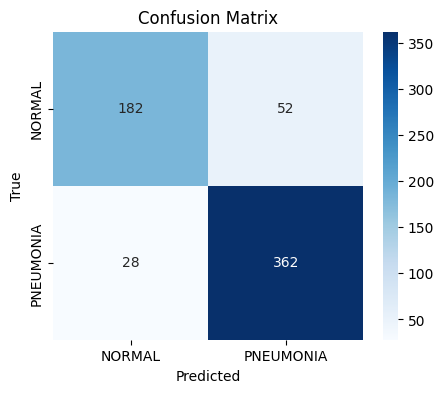

In [18]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_pred = (model.predict(test_gen) > 0.5).astype("int32")
y_true = test_gen.classes

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=list(test_gen.class_indices.keys())))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(test_gen.class_indices.keys()),
            yticklabels=list(test_gen.class_indices.keys()))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()